In [1]:
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

from model_v2_compatible import SeqNN

In [4]:
class HiCDataset(Dataset):
    def __init__(self, data_files):
        self.data = []  # To store all sequences and HiC vectors
        
        # Load and process the data files
        for file in data_files:
            print("Loading file:", file)
            file_data = torch.load(file, weights_only=True)
            
            for data in file_data:
                ohe_sequence, hic_vector = data

                # Process the OHE sequence
                ohe_sequence = ohe_sequence.squeeze(0)  # Remove singleton dimension
                
                # Ensure the sequence has the correct shape
                assert ohe_sequence.shape[0] == 4, f"Expected 4 channels, but got {ohe_sequence.shape[0]}"
                assert len(ohe_sequence.shape) == 2, f"Expected 2D shape for sequence, but got {ohe_sequence.shape}"
                
                # Add processed pair to the data list
                self.data.append((ohe_sequence, hic_vector))
        
        print(f"Total sequences loaded: {len(self.data)}")
        
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Fetch the preprocessed (ohe_sequence, hic_vector) pair from memory
        ohe_sequence, hic_vector = self.data[idx]
        return ohe_sequence, hic_vector

In [5]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = SeqNN()
model.load_state_dict(torch.load("/scratch1/smaruj/Akita_pytorch_models/finetuned/human_models/Krietenstein2019_H1hESC/models/Akita_v2_human_Krietenstein2019_H1hESC_model0_finetuned.pth", map_location=device))
model.eval()

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [ ]:
# data_dir = "/scratch1/smaruj/train_pytorch_akita/mouse_data/Hsieh2019_mESC_data_local"
# test_fold = "fold0"

# all_files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(".pt")]
# test_files = [f for f in all_files if test_fold in f]

In [6]:
BED_FILE = "/project2/fudenber_735/tensorflow_models/akita/v2/data/hg38/sequences.bed"

In [7]:
df = pd.read_csv(BED_FILE, sep="\t", header=None, names=["chrom", "start", "end", "fold"])

In [8]:
FOLD = 0 # test
# FOLD = 1 # valid
# FOLD = 2 # train

# FOLD = 3
# FOLD = 4
# FOLD = 5
# FOLD = 6
# FOLD = 7

In [9]:
df_select_fold = df[df["fold"] == f"fold{FOLD}"].reset_index(drop=True)

In [10]:
test_files = [f"/scratch1/smaruj/Akita_pytorch_training_data/human_data/Krietenstein2019_HFF/fold{FOLD}_{i}.pt" for i in range(8)]

In [11]:
test_dataset = HiCDataset(test_files)

Loading file: /scratch1/smaruj/Akita_pytorch_training_data/human_data/Krietenstein2019_HFF/fold0_0.pt
Loading file: /scratch1/smaruj/Akita_pytorch_training_data/human_data/Krietenstein2019_HFF/fold0_1.pt
Loading file: /scratch1/smaruj/Akita_pytorch_training_data/human_data/Krietenstein2019_HFF/fold0_2.pt
Loading file: /scratch1/smaruj/Akita_pytorch_training_data/human_data/Krietenstein2019_HFF/fold0_3.pt
Loading file: /scratch1/smaruj/Akita_pytorch_training_data/human_data/Krietenstein2019_HFF/fold0_4.pt
Loading file: /scratch1/smaruj/Akita_pytorch_training_data/human_data/Krietenstein2019_HFF/fold0_5.pt
Loading file: /scratch1/smaruj/Akita_pytorch_training_data/human_data/Krietenstein2019_HFF/fold0_6.pt
Loading file: /scratch1/smaruj/Akita_pytorch_training_data/human_data/Krietenstein2019_HFF/fold0_7.pt
Total sequences loaded: 717


In [12]:
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False, num_workers=4, pin_memory=True)

In [13]:
import numpy as np

In [14]:
def calculate_insulation_profile(contact_map, window=16):
    """
    Calculate insulation score across the diagonal of a contact map.

    Parameters
    ----------
    contact_map : np.ndarray
        2D symmetric matrix (e.g., 512x512) representing contact frequencies.
    window : int
        Half-width of the diamond window. The full diamond has size (2*window x 2*window).

    Returns
    -------
    insulation_scores : np.ndarray
        Vector of insulation scores for positions where the full diamond fits.
        Length = map_size - 2 * window
    """
    map_size = contact_map.shape[0]
    scores = []

    for i in range(window, map_size - window):
        # Extract a diamond: rows i-window to i, cols i to i+window
        diamond = contact_map[i - window : i, i : i + window]
        scores.append(np.nanmean(diamond))

    return np.array(scores)

In [15]:
# Run model on train set, one of the folds
all_preds = []
all_targets = []
with torch.no_grad():
    for ohe_sequence, hic_vector in test_loader:
        ohe_sequence = ohe_sequence.to(device)
        hic_vector = hic_vector.to(device)
        
        outputs = model(ohe_sequence)
        all_preds.append(outputs.cpu())
        all_targets.append(hic_vector.cpu())

/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv1d(input, weight, bias, self.stride,


In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_map(matrix, vmin=-0.6, vmax=0.6, palette="RdBu_r", width=5, height=5):
    fig, axes = plt.subplots(1, 1, figsize=(width, height))

    sns.heatmap(
        matrix,
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        cmap=palette,
        square=True,
        xticklabels=False,
        yticklabels=False,
        ax=axes
    )

    plt.tight_layout()
    plt.show()
    

# Helper function to set diagonal elements to a specific value
def set_diag(matrix, value, k):
    # Explicitly set the diagonal to 'value' (in this case, np.nan) for each k
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value


def from_upper_triu(vector_repr, matrix_len, num_diags):
    # Ensure vector_repr is a NumPy array (if it's a PyTorch tensor, convert it)
    if isinstance(vector_repr, torch.Tensor):
        vector_repr = vector_repr.detach().flatten().cpu().numpy()  # Flatten and convert to NumPy array

    # Initialize a zero matrix of shape (matrix_len, matrix_len)
    z = np.zeros((matrix_len, matrix_len))

    # Get the indices for the upper triangular matrix
    triu_tup = np.triu_indices(matrix_len, num_diags)
    
    # Assign the values from the vector_repr to the upper triangular part of the matrix
    z[triu_tup] = vector_repr

    # Set the diagonals specified by num_diags to np.nan
    for i in range(-num_diags + 1, num_diags):
        set_diag(z, np.nan, i)

    # Ensure the matrix is symmetric
    return z + z.T

In [17]:
def find_longest_flat_region_robust(
    insul_profile,
    std_window=50,
    std_threshold=0.025,
    min_length=100,
    edge_margin=50
):
    """
    Detects the longest flat region using a sliding window std-based filter.
    Preserves full region length as long as it doesn't violate edge_margin.
    """
    valid = ~np.isnan(insul_profile)
    y = insul_profile[valid]
    indices = np.where(valid)[0]

    flat_mask = np.zeros_like(y, dtype=bool)

    # Sliding window std filter
    for i in range(std_window, len(y) - std_window):
        window_vals = y[i - std_window // 2 : i + std_window // 2]
        if np.std(window_vals) < std_threshold:
            flat_mask[i] = True

    max_len = 0
    best_start = best_end = None

    i = 0
    while i < len(flat_mask):
        if flat_mask[i]:
            start = i
            while i < len(flat_mask) and flat_mask[i]:
                i += 1
            end = i
            region_start = indices[start]
            region_end = indices[end - 1]

            region_len = region_end - region_start
            if (
                region_len >= min_length and
                region_start >= edge_margin and
                region_end <= len(insul_profile) - edge_margin
            ):
                if region_len > max_len:
                    max_len = region_len
                    best_start = region_start
                    best_end = region_end
        else:
            i += 1

    return best_start, best_end



In [18]:
# Convert lists to tensors
all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)

In [19]:
from scipy.stats import pearsonr

In [20]:
pearson_corr, _ = pearsonr(all_targets.flatten().numpy(), all_preds.flatten().numpy())

In [21]:
print(f"Pearson correlation: {pearson_corr:.4f}")

Pearson correlation: 0.6631


In [22]:
# If your tensors are PyTorch and need conversion
targets = all_targets.detach().cpu().numpy()  # shape (N, L)
preds = all_preds.detach().cpu().numpy()

r_vals = []
for i in range(len(targets)):
    r, _ = pearsonr(targets[i].flatten(), preds[i].flatten())
    r_vals.append(r)

r_vals = np.array(r_vals)
num_above_R = np.sum(r_vals > pearson_corr)

high_corr_indices = [i for i, r in enumerate(r_vals) if r > pearson_corr]

print(f"{num_above_R} / {len(r_vals)} maps have Pearson R > {pearson_corr}")

326 / 717 maps have Pearson R > 0.6631020903587341


In [23]:
df_select_fold["PearsonR"] = r_vals

In [24]:
highR_df = df_select_fold[df_select_fold["PearsonR"] > pearson_corr]

In [25]:
matrix_len = 512
num_diags = 2
window = 16
# Ensure highR_df has a column 'index' or similar pointing to the right row in all_preds/all_targets
flat_starts = []
flat_ends = []

for index in highR_df.index:
    true_matrix = from_upper_triu(all_targets[index, :, :], matrix_len, num_diags)
    pred_matrix = from_upper_triu(all_preds[index, :], matrix_len, num_diags)
    
    true_insul = calculate_insulation_profile(true_matrix, window)
    pred_insul = calculate_insulation_profile(pred_matrix, window)

    map_size = true_matrix.shape[0]
    pad_len = window
    x_full = np.arange(map_size)

    # Pad insulation scores with NaNs to align with full heatmap axis
    true_insul_full = np.full(map_size, np.nan)
    pred_insul_full = np.full(map_size, np.nan)
    true_insul_full[pad_len : map_size - pad_len] = true_insul
    pred_insul_full[pad_len : map_size - pad_len] = pred_insul
    
    # Find longest flat region in predicted insulation
    flat_start, flat_end = find_longest_flat_region_robust(pred_insul_full,
                                                            std_window=40,
                                                            std_threshold=0.025,
                                                            min_length=100,
                                                            edge_margin=50)

    flat_starts.append(flat_start)
    flat_ends.append(flat_end)


In [26]:
highR_df["flat_start"] = flat_starts
highR_df["flat_end"] = flat_ends

/tmp/SLURM_2199470/ipykernel_1269974/2052532076.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  highR_df["flat_start"] = flat_starts
/tmp/SLURM_2199470/ipykernel_1269974/2052532076.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  highR_df["flat_end"] = flat_ends


In [27]:
valid_flats_df = highR_df.dropna(subset=["flat_start", "flat_end"])

In [28]:
len(valid_flats_df)

81

In [29]:
import matplotlib.patches as patches

In [30]:
def plot_true_vs_pred_with_insulation(true_matrix, pred_matrix, flat_start, flat_end, window=16, vmin=-0.6, vmax=0.6, palette="RdBu_r", matrix_title="Example", figsize=(10, 8)):
    # Compute insulation scores
    true_insul = calculate_insulation_profile(true_matrix, window)
    pred_insul = calculate_insulation_profile(pred_matrix, window)

    map_size = true_matrix.shape[0]
    pad_len = window
    x_full = np.arange(map_size)

    # Pad insulation scores with NaNs to align with full heatmap axis
    true_insul_full = np.full(map_size, np.nan)
    pred_insul_full = np.full(map_size, np.nan)
    true_insul_full[pad_len : map_size - pad_len] = true_insul
    pred_insul_full[pad_len : map_size - pad_len] = pred_insul
    
    # Create 2x2 subplot grid: heatmaps on top, insulation profiles on bottom
    fig, axes = plt.subplots(2, 2, figsize=figsize, height_ratios=[5, 1])

    # Plot true heatmap
    sns.heatmap(
        true_matrix,
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        cmap=palette,
        square=True,
        xticklabels=False,
        yticklabels=False,
        ax=axes[0, 0]
    )
    axes[0, 0].set_title(f"{matrix_title} - True")

    # Plot predicted heatmap
    sns.heatmap(
        pred_matrix,
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        cmap=palette,
        square=True,
        xticklabels=False,
        yticklabels=False,
        ax=axes[0, 1]
    )
    axes[0, 1].set_title(f"{matrix_title} - Pred")

    # Plot insulation score for true
    axes[1, 0].plot(x_full, true_insul_full, label="True", color="black")
    axes[1, 0].set_xlim(0, map_size)
    axes[1, 0].set_title("Insulation Score (True)")
    axes[1, 0].set_xlabel("Position")
    axes[1, 0].set_ylabel("Insulation")
    axes[1, 0].margins(x=0)

    # Highlight flat region on the predicted heatmap
    if flat_start is not None and flat_end is not None:
        rect = patches.Rectangle(
            (flat_start, flat_start),                  # (x, y) of bottom-left corner
            flat_end - flat_start,                     # width
            flat_end - flat_start,                     # height
            linewidth=1.5,
            edgecolor='red',
            facecolor='none'
        )
    axes[0, 1].add_patch(rect)  # Add rectangle to predicted heatmap axis
    
    
    # Plot insulation score for pred
    axes[1, 1].plot(x_full, pred_insul_full, label="Pred", color="blue")
    axes[1, 1].set_xlim(0, map_size)
    axes[1, 1].set_title("Insulation Score (Pred)")
    axes[1, 1].set_xlabel("Position")
    axes[1, 1].set_ylabel("Insulation")
    axes[1, 1].margins(x=0)

    if flat_start is not None and flat_end is not None:
        axes[1, 1].axvspan(flat_start, flat_end, color='red', alpha=0.3, label="Flat region")

    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()


Index: 0, Flat region: 112.0–218.0


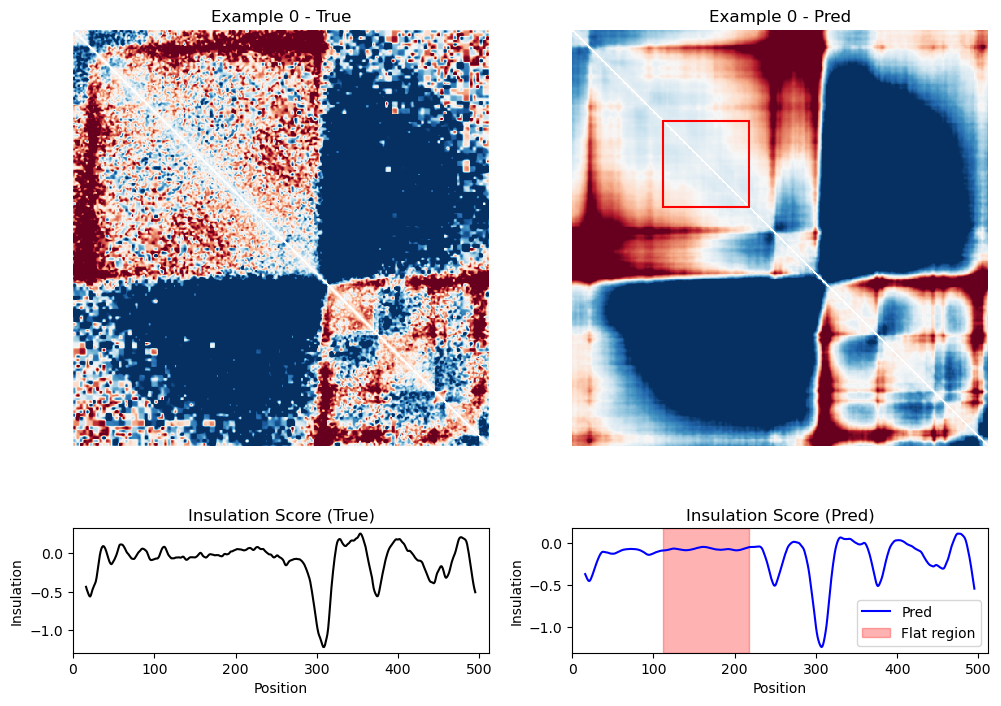

Index: 4, Flat region: 221.0–455.0


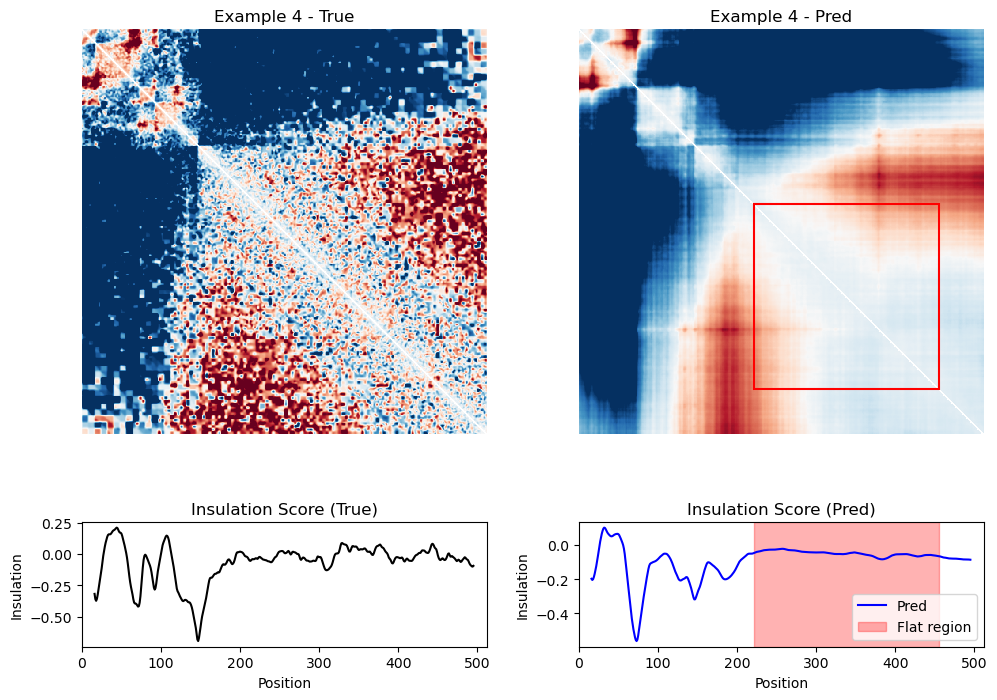

Index: 10, Flat region: 56.0–192.0


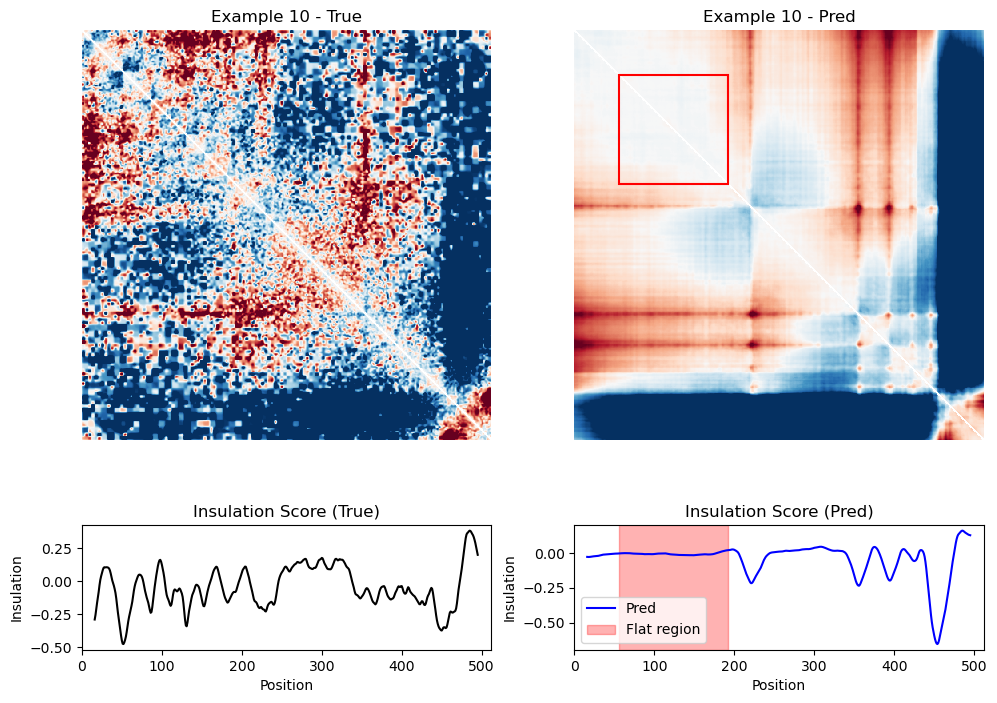

In [31]:
showed = 0

for index, row in valid_flats_df.iterrows():
    if showed >= 3:
        break
    true_mat = from_upper_triu(all_targets[index, :, :], matrix_len, num_diags)
    pred_mat = from_upper_triu(all_preds[index, :], matrix_len, num_diags)
    flat_start = row["flat_start"]
    flat_end = row["flat_end"]
    
    print(f"Index: {index}, Flat region: {flat_start}–{flat_end}")
    plot_true_vs_pred_with_insulation(true_mat, pred_mat, flat_start, flat_end, matrix_title=f"Example {index}")
    showed += 1

In [ ]:
# valid_flats_df

In [32]:
# moving the flat regions to the center
# such that it's easier to compare between maps and calculate stats

def recenter_flat_region(row, cropping=64, map_size=512, bin_size=2048):
    halfpoint = (map_size // 2) + cropping
    
    flat_region_half = (row["flat_end"] - row["flat_start"]) // 2
    flat_region_center = row["flat_start"] + flat_region_half + cropping
    
    difference = flat_region_center - halfpoint

    new_start = int(row["start"] + (difference * bin_size))
    new_end = int(row["end"] + (difference * bin_size))

    centered_flat_start = int(halfpoint - flat_region_half - cropping)
    centered_flat_end = int(halfpoint + flat_region_half - cropping)

    return pd.Series({
        "centered_start": new_start,
        "centered_end": new_end,
        "centered_flat_start": centered_flat_start,
        "centered_flat_end": centered_flat_end
    })


In [33]:
valid_flats_df[["centered_start", "centered_end", "centered_flat_start", "centered_flat_end"]] = valid_flats_df.apply(recenter_flat_region, axis=1)

/tmp/SLURM_2199470/ipykernel_1269974/1917242987.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_flats_df[["centered_start", "centered_end", "centered_flat_start", "centered_flat_end"]] = valid_flats_df.apply(recenter_flat_region, axis=1)
/tmp/SLURM_2199470/ipykernel_1269974/1917242987.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_flats_df[["centered_start", "centered_end", "centered_flat_start", "centered_flat_end"]] = valid_flats_df.apply(recenter_flat_region, axis=1)
/tmp/SLURM_21994

In [34]:
def remove_close_regions(df, chrom_col="chrom", start_col="centered_start", min_spacing=300_000, seed=None):
    """
    Removes regions that are too close together along the genome.
    
    Keeps one region per `min_spacing` window along each chromosome, chosen randomly.

    Parameters:
        df (pd.DataFrame): Input dataframe with genomic intervals.
        chrom_col (str): Column name for chromosome.
        start_col (str): Column name for region start.
        min_spacing (int): Minimum spacing between retained regions (in bp).
        seed (int or None): Random seed for reproducibility.

    Returns:
        pd.DataFrame: Filtered DataFrame with spaced-apart regions.
    """
    if seed is not None:
        np.random.seed(seed)

    df_sorted = df.sort_values(by=[chrom_col, start_col]).reset_index(drop=True)
    keep_indices = []

    last_chrom = None
    last_kept_start = -np.inf

    for i, row in df_sorted.iterrows():
        chrom = row[chrom_col]
        start = row[start_col]

        if chrom != last_chrom or start - last_kept_start >= min_spacing:
            keep_indices.append(i)
            last_chrom = chrom
            last_kept_start = start
        else:
            # Within spacing — keep randomly with 50% chance
            if np.random.rand() < 0.5:
                keep_indices[-1] = i
                last_kept_start = start
            # else skip

    return df_sorted.loc[keep_indices].reset_index(drop=True)


In [35]:
# keeping only those windows which don't overlap more than 300kb

non_overlapping_df = remove_close_regions(valid_flats_df, seed=42)

In [36]:
len(non_overlapping_df)

64

In [ ]:
# valid_flats_df = valid_flats_df.drop_duplicates(subset=['chrom', 'centered_start', 'centered_end'])

In [ ]:
# len(valid_flats_df)

In [37]:
non_overlapping_df.to_csv(f"/scratch1/smaruj/generate_cell_type_specific_features/fold{FOLD}_HUMAN_selected_genomic_windows_centered.tsv", sep="\t", index=False)